In [1]:
# --- Importy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets, model_selection, preprocessing, metrics, neighbors, linear_model

In [2]:
# ============================================
#  Wczytywanie danych
# ============================================

iris = datasets.load_iris()
X, y = iris.data, iris.target

print("Liczba próbek:", X.shape[0])
print("Liczba cech:", X.shape[1])
print("Etykiety klas:", iris.target_names)

# TODO: Wyświetl pierwsze 5 wierszy danych w formie DataFrame
# (użyj pd.DataFrame i nazw cech iris.feature_names)

Liczba próbek: 150
Liczba cech: 4
Etykiety klas: ['setosa' 'versicolor' 'virginica']


In [3]:
# ============================================
# Podział danych na zbiór treningowy i testowy   (po co się to robi?)
# ============================================

from sklearn.model_selection import train_test_split

# TODO: podziel dane X, y na train/test (np. test_size=0.3, random_state=43)
# X_train, X_test, y_train, y_test = ...

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=43

)


In [4]:
# ============================================
# Skalowanie danych (po co się to robi?)
# ============================================

from sklearn.preprocessing import StandardScaler

# TODO: utwórz obiekt StandardScaler i przeskaluj X_train oraz X_test

# utworzenie obiektu skalera
scaler = StandardScaler()

# dopasowanie do X_train i transformacja
X_train_scaled = scaler.fit_transform(X_train)

# transformacja X_test (bez ponownego fit!)
X_test_scaled = scaler.transform(X_test)

In [5]:
# ============================================
# Klasyfikacja KNN
# ============================================

from sklearn.neighbors import KNeighborsClassifier

# TODO: utwórz model KNN z np. n_neighbors=5 i wytrenuj go na zbiorze treningowym


# TODO: dokonaj predykcji na zbiorze testowym
# y_pred = ...

# TODO: oblicz accuracy_score i wyświetl wynik

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# utworzenie i trenowanie modelu
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

# predykcja na zbiorze testowym
y_pred = knn.predict(X_test_scaled)

# obliczenie accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)



Accuracy: 0.9555555555555556


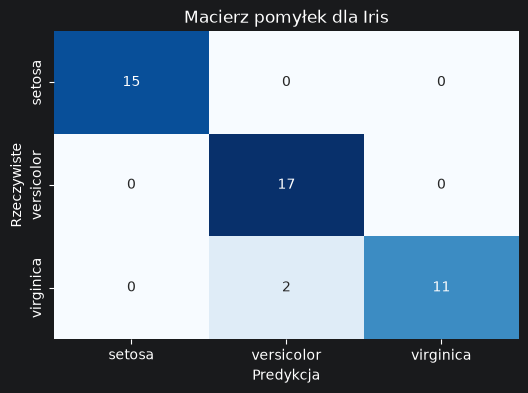


Raport klasyfikacji:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.89      1.00      0.94        17
   virginica       1.00      0.85      0.92        13

    accuracy                           0.96        45
   macro avg       0.96      0.95      0.95        45
weighted avg       0.96      0.96      0.95        45



In [6]:
# ============================================
# Macierz pomyłek i raport
# ============================================

from sklearn.metrics import confusion_matrix, classification_report

# TODO: wygeneruj macierz pomyłek i raport klasyfikacji

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# załóżmy, że klasy to gatunki irysów
class_names = ["setosa", "versicolor", "virginica"]

# macierz pomyłek
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywiste")
plt.title("Macierz pomyłek dla Iris")
plt.show()

# raport klasyfikacji
print("\nRaport klasyfikacji:\n", classification_report(y_test, y_pred, target_names=class_names))




In [7]:
# ============================================
# Regresja liniowa
# ============================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
diabetes = datasets.load_diabetes()

X, y = diabetes.data, diabetes.target

# TODO: podziel dane na train/test i przetrenuj model LinearRegression


# TODO: oblicz i wyświetl mean_squared_error

# podział danych na train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=43
)

# utworzenie i trenowanie modelu regresji liniowej
model = LinearRegression()
model.fit(X_train, y_train)

# predykcja
y_pred = model.predict(X_test)

# obliczenie błędu średniokwadratowego
mse = mean_squared_error(y_test, y_pred)
R = model.score(X_test, y_test)
print("R^2:", R)
print("Mean Squared Error:", mse)



R^2: 0.4816506895496181
Mean Squared Error: 3051.1668514623907


In [9]:
# ============================================
# Zadanie samodzielne
# ============================================

"""
Zadanie:
1. Wybierz inny klasyfikator (np. DecisionTreeClassifier lub SVC)
2. Wytrenuj go na zbiorze iris
3. Porównaj wyniki (accuracy) z modelem KNN
4. Wypisz krótką interpretację wyników
"""

# TODO: zaimplementuj rozwiązanie tutaj

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Ad 2. Utworzenie i trenowanie modelu Drzewa Decyzyjnego na zbiorze iris
X_iris, y_iris = iris.data, iris.target
X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=43
)

tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train_iris, y_train_iris)

# Predykcja na zbiorze testowym
y_pred_tree = tree_clf.predict(X_test_iris)

# Obliczenie dokładności (accuracy)
accuracy_tree = accuracy_score(y_test_iris, y_pred_tree)
print(f"Dokładność modelu Decision Tree: {accuracy_tree:.4f}")

# Model KNN osiągnął niewielką wyższą dokładność na tym konkretnym podziale danych. Oznacza to, że klasyfikacja oparta na "sąsiedztwie" punktów danych okazała się trochę skuteczniejsza ale nie znacząco.


Dokładność modelu Decision Tree: 0.9333
